In [ ]:
# Step 1: Import libraries
import seaborn as sns
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Step 2: Load dataset from seaborn
iris = sns.load_dataset('iris')

# Step 3: Select features (drop species since it's the label)
X = iris.drop(columns=['species'])

# Step 4: Apply KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)

# Step 5: Add cluster labels to dataset
iris['cluster'] = kmeans.labels_

# Step 6: Visualize (using first two features)
plt.scatter(iris['sepal_length'], iris['sepal_width'], c=iris['cluster'])
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('K-Means Clustering on Iris Dataset')
plt.show()

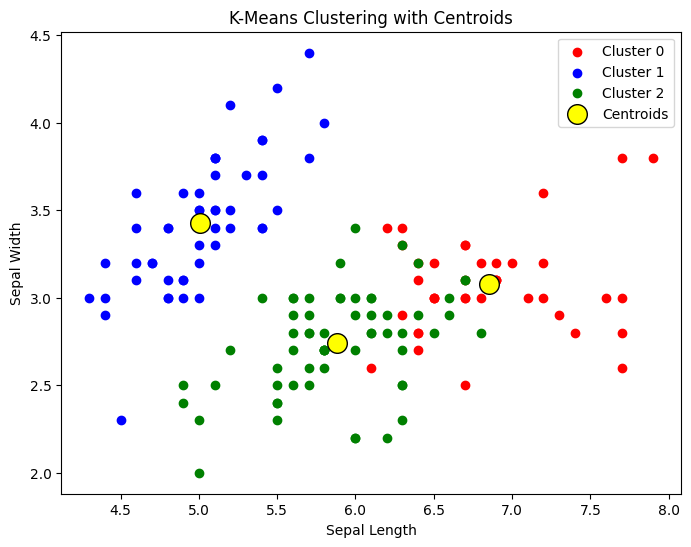

New data point [[5.1 3.5 1.4 0.2]] belongs to Cluster 1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [6]:
# Step 1: Import libraries
import seaborn as sns
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

# Step 2: Load dataset
iris = sns.load_dataset('iris')

# Step 3: Select features
X = iris.drop(columns=['species'])

# Step 4: Apply KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)

# Step 5: Add cluster labels
iris['cluster'] = kmeans.labels_

# Step 6: Plot clusters (using first two features)
plt.figure(figsize=(8,6))

colors = ['red', 'blue', 'green']

for i in range(3):
    cluster_data = iris[iris['cluster'] == i]
    plt.scatter(cluster_data['sepal_length'],
                cluster_data['sepal_width'],
                color=colors[i],
                label=f'Cluster {i}')

# Plot centroids (only first two features)
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1],
            s=200, c='yellow', marker='o', edgecolors='black',
            label='Centroids')

plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('K-Means Clustering with Centroids')
plt.legend()
plt.show()

# Step 7: Take new input and predict cluster
# Format: [sepal_length, sepal_width, petal_length, petal_width]
new_sample = np.array([[5.1, 3.5, 1.4, 0.2]])

predicted_cluster = kmeans.predict(new_sample)

print(f"New data point {new_sample} belongs to Cluster {predicted_cluster[0]}")

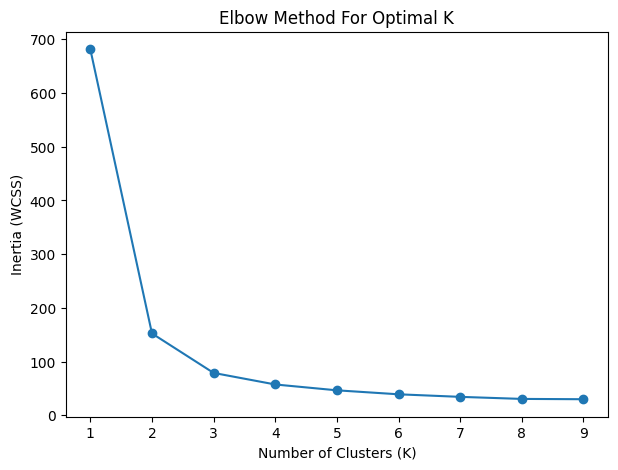

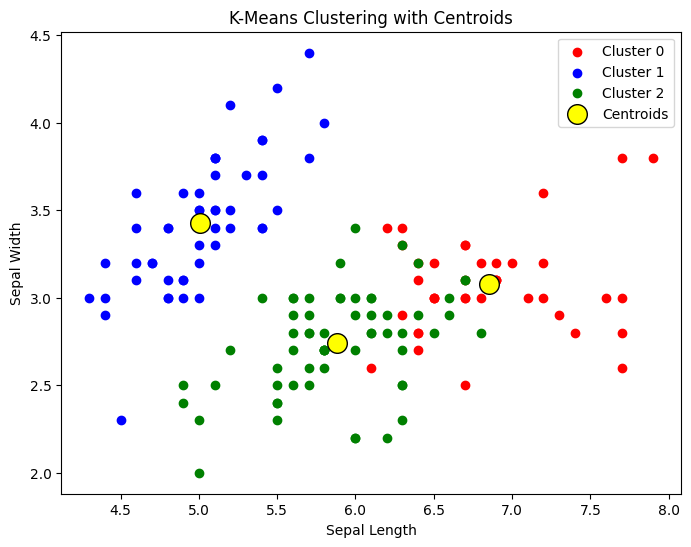

New data point [[5.1 3.5 1.4 0.2]] belongs to Cluster 1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [7]:
# Step 1: Import libraries
import seaborn as sns
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

# Step 2: Load dataset
iris = sns.load_dataset('iris')

# Step 3: Select features
X = iris.drop(columns=['species'])

# -------------------------------
# Step 4: Elbow Method
# -------------------------------
inertia = []
K_range = range(1, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    inertia.append(km.inertia_)

# Plot Elbow Graph
plt.figure(figsize=(7,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method For Optimal K')
plt.show()

# -------------------------------
# Step 5: Apply KMeans (choose K=3 based on elbow)
# -------------------------------
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)

# Step 6: Add cluster labels
iris['cluster'] = kmeans.labels_

# -------------------------------
# Step 7: Visualization
# -------------------------------
plt.figure(figsize=(8,6))

colors = ['red', 'blue', 'green']

for i in range(3):
    cluster_data = iris[iris['cluster'] == i]
    plt.scatter(cluster_data['sepal_length'],
                cluster_data['sepal_width'],
                color=colors[i],
                label=f'Cluster {i}')

# Centroids
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1],
            s=200, c='yellow', marker='o', edgecolors='black',
            label='Centroids')

plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('K-Means Clustering with Centroids')
plt.legend()
plt.show()

# -------------------------------
# Step 8: Predict new sample
# -------------------------------
new_sample = np.array([[5.1, 3.5, 1.4, 0.2]])

predicted_cluster = kmeans.predict(new_sample)

print(f"New data point {new_sample} belongs to Cluster {predicted_cluster[0]}")